In [7]:
import torch
import matplotlib.pyplot as plt
from models.mlp import run

In [8]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

Using device: mps


In [3]:
path = "./normalized_images"

num_epochs = 20
lr = 1e-4

model, train_losses, eval_losses, eval_preds, eval_labels = run(path, device, num_epochs=num_epochs, lr=lr)

-- MLP | Epochs: 20 | LR: 0.0001
Epoch 1/20 - Train Loss: 1.0110, Eval Loss: 0.2572
Epoch 2/20 - Train Loss: 0.3702, Eval Loss: 0.2740
Epoch 3/20 - Train Loss: 0.3009, Eval Loss: 0.2605
Epoch 4/20 - Train Loss: 0.2743, Eval Loss: 0.2320
Epoch 5/20 - Train Loss: 0.2658, Eval Loss: 0.2197
Epoch 6/20 - Train Loss: 0.2465, Eval Loss: 0.2231
Epoch 7/20 - Train Loss: 0.2416, Eval Loss: 0.2146
Epoch 8/20 - Train Loss: 0.2390, Eval Loss: 0.2130
Epoch 9/20 - Train Loss: 0.2330, Eval Loss: 0.2115
Epoch 10/20 - Train Loss: 0.2297, Eval Loss: 0.2025
Epoch 11/20 - Train Loss: 0.2250, Eval Loss: 0.2056
Epoch 12/20 - Train Loss: 0.2235, Eval Loss: 0.2193
Epoch 13/20 - Train Loss: 0.2155, Eval Loss: 0.2006
Epoch 14/20 - Train Loss: 0.2188, Eval Loss: 0.2097
Epoch 15/20 - Train Loss: 0.2217, Eval Loss: 0.2055
Epoch 16/20 - Train Loss: 0.2162, Eval Loss: 0.2103
Epoch 17/20 - Train Loss: 0.2194, Eval Loss: 0.2124
Epoch 18/20 - Train Loss: 0.2075, Eval Loss: 0.2111
Epoch 19/20 - Train Loss: 0.2039, Eval L

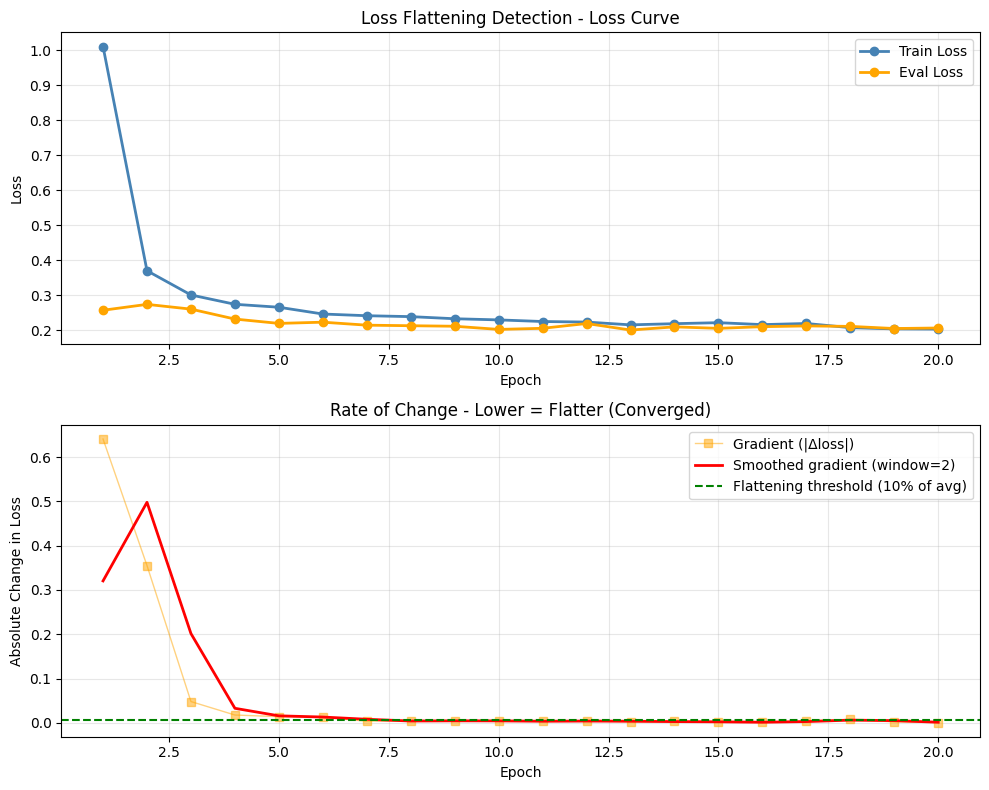


✓ Loss appears to flatten starting around epoch 8


In [4]:
from graphs import plot_loss_flattening
plot_loss_flattening(train_losses, eval_losses, window_size=2)

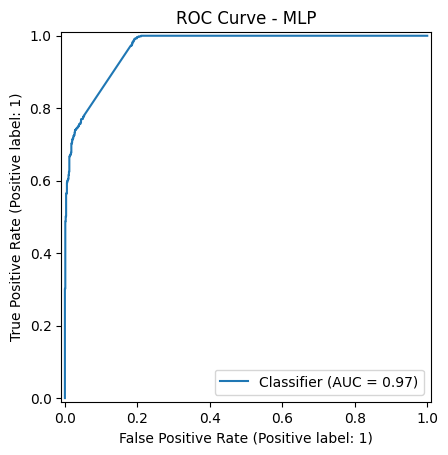

In [5]:
from sklearn.metrics import RocCurveDisplay
RocCurveDisplay.from_predictions(eval_labels, eval_preds)
plt.title("ROC Curve - MLP")
plt.show()

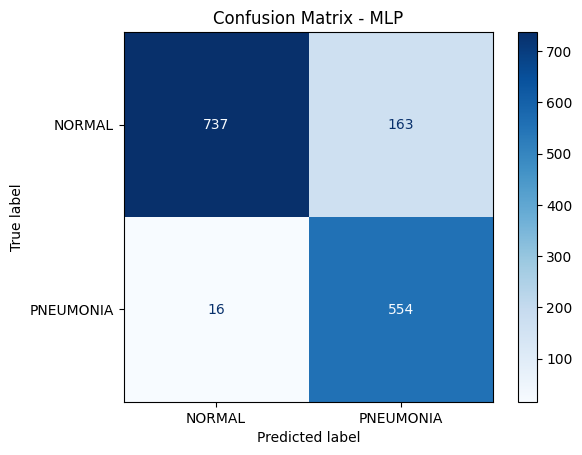

In [6]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(eval_labels, eval_preds.round(), display_labels=["NORMAL", "PNEUMONIA"], cmap="Blues")
plt.title("Confusion Matrix - MLP")
plt.show()